In [ ]:
import torch
print(torch.cuda.is_available())

False


In [ ]:
!pip install transformers datasets -q

In [ ]:
import pandas as pd
import numpy as np
import torch
import warnings

warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

from transformers import DistilBertTokenizerFast
from transformers import DistilBertForSequenceClassification
from transformers import Trainer
from transformers import TrainingArguments
from transformers import DataCollatorWithPadding

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df = pd.read_csv('/content/drive/MyDrive/WELFake_Dataset.csv')
df.head()

,Unnamed: 0,title,text,label
0,0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,No comment is expected from Barack Obama Membe...,1
1,1,NaN,Did they post their votes for Hillary already?,1
2,2,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...,"Now, most of the demonstrators gathered last ...",1
3,3,"Bobby Jindal, raised Hindu, uses story of Chri...",A dozen politically active pastors came here f...,0
4,4,SATAN 2: Russia unvelis an image of its terrif...,"The RS-28 Sarmat missile, dubbed Satan 2, will...",1


In [ ]:
if 'Unnamed: 0' in df.columns:
    df = df.drop(columns=['Unnamed: 0'])

df = df.dropna()

df['content'] = df['title'] + " " + df['text']
df = df[['content', 'label']]

df.head()

,content,label
0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,1
2,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...,1
3,"Bobby Jindal, raised Hindu, uses story of Chri...",0
4,SATAN 2: Russia unvelis an image of its terrif...,1
5,About Time! Christian Group Sues Amazon and SP...,1


In [ ]:
X = df['content']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
X_train = X_train[:3000]
y_train = y_train[:3000]

X_test = X_test[:1000]
y_test = y_test[:1000]

In [ ]:
tokenizer = DistilBertTokenizerFast.from_pretrained('distilbert-base-uncased')

train_encodings = tokenizer(
    list(X_train),
    truncation=True,
    padding=True,
    max_length=64   # 🔥 very important
)

test_encodings = tokenizer(
    list(X_test),
    truncation=True,
    padding=True,
    max_length=64
)

In [ ]:
class NewsDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = list(labels)

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

In [ ]:
train_dataset = NewsDataset(train_encodings, y_train)
test_dataset = NewsDataset(test_encodings, y_test)

In [ ]:
model = DistilBertForSequenceClassification.from_pretrained(
    'distilbert-base-uncased',
    num_labels=2
)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

In [ ]:
training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=2,
    per_device_train_batch_size=2,   # 🔥 small batch
    per_device_eval_batch_size=2,
    logging_steps=100,
    report_to="none"
)

In [ ]:
def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)

    acc = accuracy_score(labels, preds)
    prec = precision_score(labels, preds)
    rec = recall_score(labels, preds)
    f1 = f1_score(labels, preds)

    return {
        'accuracy': acc,
        'precision': prec,
        'recall': rec,
        'f1': f1
    }

In [ ]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics,
    data_collator=data_collator
)

In [ ]:
trainer.train()

Step,Training Loss
100,0.595042
200,0.309116
300,0.295705
400,0.241288
500,0.218432
600,0.304076
700,0.237309
800,0.342559
900,0.290806
1000,0.171274


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=3000, training_loss=0.17274543338020643, metrics={'train_runtime': 3458.9254, 'train_samples_per_second': 1.735, 'train_steps_per_second': 0.867, 'total_flos': 99350548992000.0, 'train_loss': 0.17274543338020643, 'epoch': 2.0})

In [ ]:
results = trainer.evaluate()

print("Accuracy:", results['eval_accuracy'])
print("Precision:", results['eval_precision'])
print("Recall:", results['eval_recall'])
print("F1 Score:", results['eval_f1'])

Accuracy: 0.96
Precision: 0.9593810444874274
Recall: 0.9631067961165048
F1 Score: 0.9612403100775194


In [ ]:
logs = trainer.state.log_history

train_loss = []
steps = []

for log in logs:
    if 'loss' in log:
        train_loss.append(log['loss'])
        steps.append(log['step'])

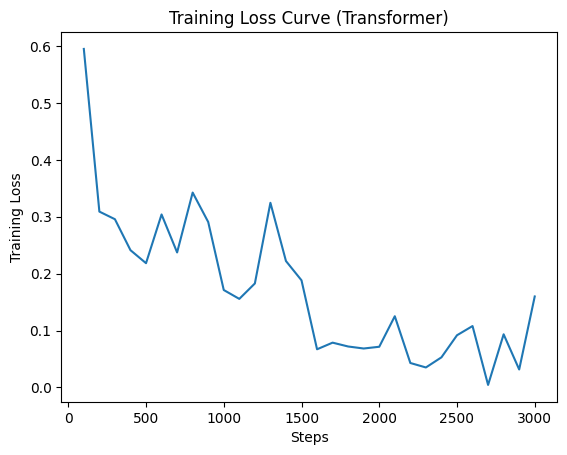

In [ ]:
import matplotlib.pyplot as plt

plt.plot(steps, train_loss)
plt.xlabel("Steps")
plt.ylabel("Training Loss")
plt.title("Training Loss Curve (Transformer)")
plt.show()

In [ ]:
import pandas as pd

results_df = pd.DataFrame([results])
results_df

,eval_loss,eval_accuracy,eval_precision,eval_recall,eval_f1,eval_runtime,eval_samples_per_second,eval_steps_per_second,epoch
0,0.214569,0.96,0.959381,0.963107,0.96124,146.1779,6.841,3.42,2.0
